In [24]:
import requests as req 
import numpy as np 
import jax
import scipy
import matplotlib.pyplot as plt

In [ ]:
url = f'https://query1.finance.yahoo.com/v8/finance/chart/%s?interval=1d&range=100d", ticker'

req.get(url)

In [116]:
def fill_vec(vec,  vol, seed=None): 
    
    rng = np.random.default_rng(seed)
    rand_coeffs = rng.random(len(vec))
    
    #idx = np.arange(len(vec)) * vol
    steps = rng.standard_normal(len(vec)) * vol
    #vec[:] = func(idx * rand_coeffs)
    vec[:] = 100 + np.cumsum(steps)   
    return vec

func = lambda x : np.abs( np.cos(x) ) 

def fill_vec_trig(vec, func, seed=None):
    rng = np.random.default_rng(seed)
    rand_coeffs = rng.random(len(vec))
    idx = np.arange(len(vec))
    vec[:] = func(idx * rand_coeffs)
    
    return vec

vec = np.zeros(1_000)
x_3 = fill_vec(vec, 0.1, seed=43)
x_2 = fill_vec_trig(vec, func, seed=42)
func(10)

0.8390715290764524

Text(0.5, 1.0, 'Vector')

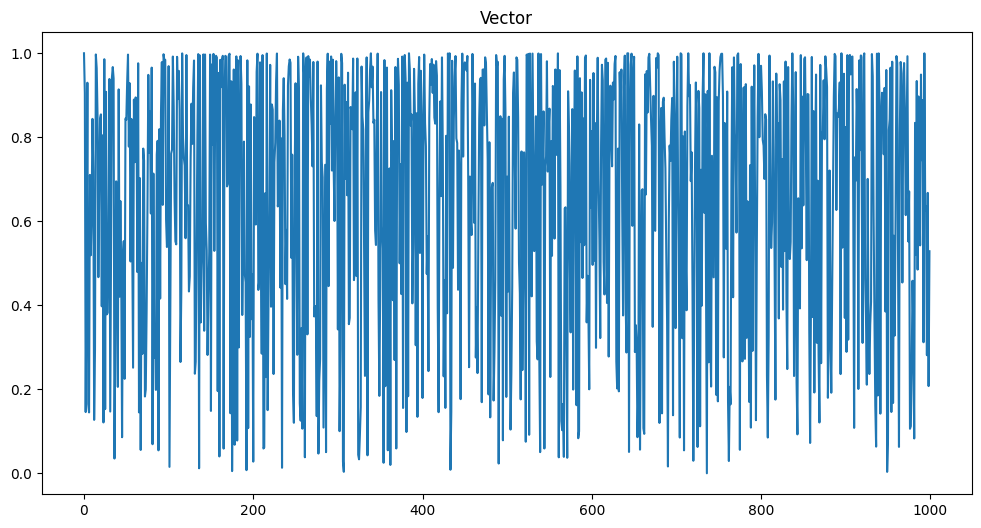

In [117]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(x_3)
ax.set_title("Vector")

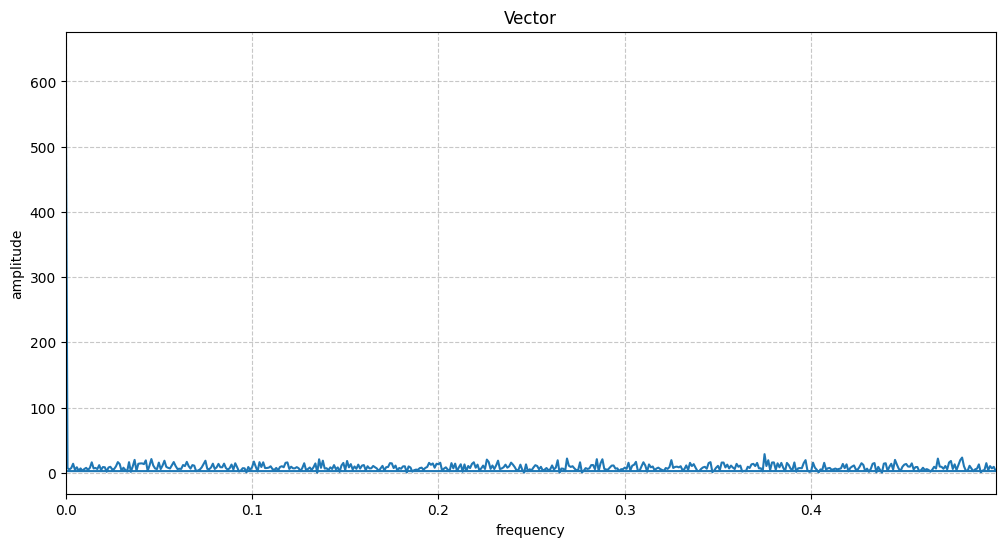

In [109]:

def fft_freqs(vec):
    fft = np.fft.fft(vec)
    freqs = np.fft.fftfreq(len(vec))
    amp = np.abs(fft)

    fig,ax = plt.subplots(figsize=(12,6))

    ax.plot(freqs, amp)
    ax.set_ylabel("amplitude")
    ax.set_xlabel("frequency")
    ax.set_title("Vector")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, max(freqs))
    
fft_freqs(x_2)